In [1]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
import regionmask

In [2]:
flo_one_k = xr.open_dataset("../data/FLO1K.ts.1960.2015.qav.nc")

In [3]:
flo_one_k

<xarray.Dataset> Size: 209GB
Dimensions:  (time: 56, lat: 21600, lon: 43200)
Coordinates:
  * time     (time) datetime64[ns] 448B 1960-01-01 1961-01-01 ... 2015-01-01
  * lat      (lat) float64 173kB -90.0 -89.99 -89.98 -89.97 ... 89.98 89.99 90.0
  * lon      (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Data variables:
    qav      (time, lat, lon) float32 209GB ...
    crs      int32 4B ...
Attributes:
    Conventions:  CF-1.6
    title:        FLO1K: global maps of mean, maximum and minimum annual stre...
    institution:  Radboud University & PBL Netherlands Environmental Assessme...
    source:       FLO1K v1.0
    scenario:     Historical run 1960-2015, yearly timesteps
    comment:      
    references:   For documentation, see Barbarossa et al. (Sci. Data, 2018)
    disclaimer:   This data was produced with the utmost care, based on metho...
    history:      Created on 2017-12-07

In [4]:
crs = flo_one_k["crs"]
crs

<xarray.DataArray 'crs' ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    long_name:                    Lon/Lat Coords in WGS84
    grid_mapping_name:            latitude_longitude
    longitude_of_prime_meridian:  0.0
    semi_major_axis:              6378137.0
    inverse_flattening:           298.257223563

In [5]:
first_date = flo_one_k["time"].values.min()
print(first_date)
last_date = flo_one_k["time"].values.max()
print(last_date)

1960-01-01T00:00:00.000000000
2015-01-01T00:00:00.000000000


In [6]:
flo_one_k["qav"]

<xarray.DataArray 'qav' (time: 56, lat: 21600, lon: 43200)> Size: 209GB
[52254720000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 448B 1960-01-01 1961-01-01 ... 2015-01-01
  * lat      (lat) float64 173kB -90.0 -89.99 -89.98 -89.97 ... 89.98 89.99 90.0
  * lon      (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Attributes:
    grid_mapping:  crs
    long_name:     mean annual streamflow
    description:   mean over the 12 mean monthly streamflow values of the year
    units:         m3/s

In [7]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
basins_eu_me.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
# aoi = area of interest
IPB = basins_eu_me.iloc[45:53]
IPB_aoi_lat = [float(IPB.total_bounds[1]), float(IPB.total_bounds[3])]
IPB_aoi_lon = [float(IPB.total_bounds[0]), float(IPB.total_bounds[2])]
print(IPB_aoi_lat, IPB_aoi_lon)



[36.05416666666669, 43.12500000000003] [-9.55061764187281, -1.4708333333333132]


In [9]:
flo_IPB_last_date = flo_one_k["qav"].sel(time = last_date,
                                  lon = slice(IPB_aoi_lon[0], IPB_aoi_lon[1]),
                                  lat = slice(IPB_aoi_lat[0], IPB_aoi_lat[1]))

In [10]:
flo_IPB_last_date

<xarray.DataArray 'qav' (lat: 848, lon: 970)> Size: 3MB
[822560 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.1 43.11 43.12
  * lon      (lon) float64 8kB -9.546 -9.537 -9.529 ... -1.488 -1.479 -1.471
    time     datetime64[ns] 8B 2015-01-01
Attributes:
    grid_mapping:  crs
    long_name:     mean annual streamflow
    description:   mean over the 12 mean monthly streamflow values of the year
    units:         m3/s

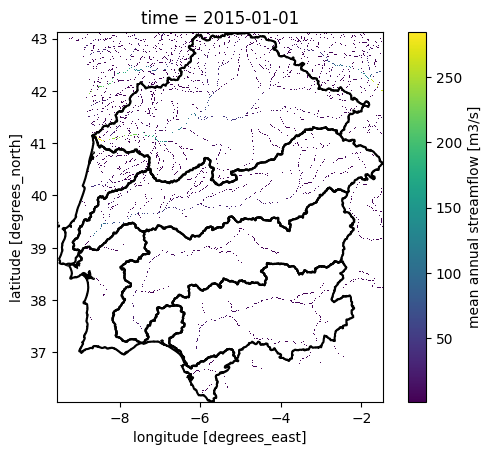

In [11]:
flo_IPB_plot = flo_IPB_last_date.where(
    flo_IPB_last_date >= 1)
fig, ax = plt.subplots()
flo_IPB_plot.plot(ax = ax)
IPB.boundary.plot(ax = ax, edgecolor = "k")
plt.show()



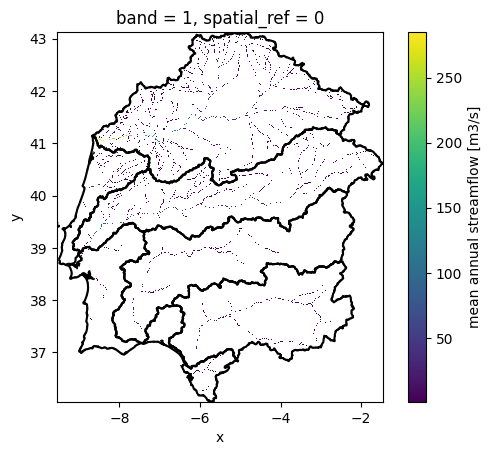

In [12]:

flo_IPB_last_date = flo_IPB_last_date.rio.write_crs(IPB.crs)

flo_IPB_last_date = flo_IPB_last_date.rio.clip(IPB.geometry.values, IPB.crs)

file_path = "../data/flo_IPB_last_date.tif"
flo_IPB_last_date.rio.to_raster(file_path)
flo_IPB_last_date = rxr.open_rasterio(file_path)

flo_IPB_plot = flo_IPB_last_date.where(
    flo_IPB_last_date >= 1)
fig, ax = plt.subplots()
flo_IPB_plot.plot(ax = ax)
IPB.boundary.plot(ax = ax, edgecolor = "k")
plt.show()